##Digit Recognition System

###Installing neccesary libraries.

In [ ]:
pip install numpy pandas matplotlib tensorflow jupyter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 910.8/910.8 kB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 99.0 MB/s eta 0:00:00
ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
   

###Importing Libraries.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import keras
from tensorflow import keras
from keras.layers import Dense
from sklearn.metrics import classification_report
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

###Importing Dataset.

In [94]:
mnist = keras.datasets.mnist.load_data()

In [100]:
(xtrain,ytrain),(xtest,ytest) = keras.datasets.mnist.load_data()

###Data Preprocesing.

In [101]:
#Before reshaping the images
xtrain.shape

(60000, 28, 28)

In [102]:
# Reshaping the data from numpy array into (1 x 784) column format

xtrain = xtrain.reshape(-1,784)
xtest = xtest.reshape(-1,784)

In [103]:
#After reshaping the images.
xtrain.shape

(60000, 784)

In [104]:
# Scaling
xtrain = xtrain/255
xtest = xtest/255

# Before normalization each pixel is in range of 0 to 255 converting it in 0.0 to 1.0

# Before normalization -
# 0 -------------------------- 255

# Black         Gray         White

# After normalization -
# 0.0 ------------------------ 1.0

# Black         Gray         White


In [109]:
xtrain[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [110]:
xtest[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [105]:
print("Training Images :", xtrain.shape)
print("Training Labels :", ytrain.shape)

print("Testing Images  :", xtest.shape)
print("Testing Labels  :", ytest.shape)

print("\nData Type :", xtrain.dtype)

print("Minimum Pixel Value :", xtrain.min())
print("Maximum Pixel Value :", xtrain.max())

Training Images : (60000, 784)
Training Labels : (60000,)
Testing Images  : (10000, 784)
Testing Labels  : (10000,)

Data Type : float64
Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


In [107]:
# Checking for the count of all digits.
unique, counts = np.unique(ytrain, return_counts=True)

for digit, count in zip(unique, counts):
    print(f"Digit {digit}: {count}")

Digit 0: 5923
Digit 1: 6742
Digit 2: 5958
Digit 3: 6131
Digit 4: 5842
Digit 5: 5421
Digit 6: 5918
Digit 7: 6265
Digit 8: 5851
Digit 9: 5949


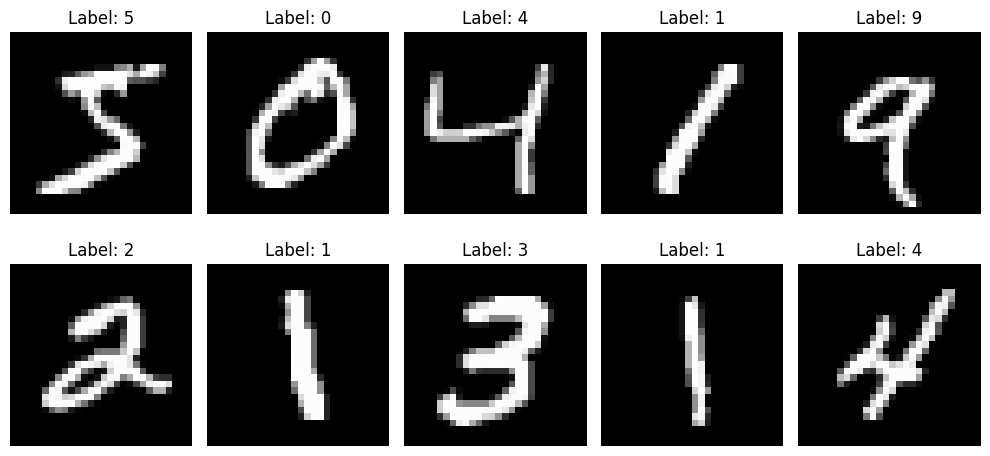

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    # Reshape the 1D array back to 28x28 for plotting
    plt.imshow(xtrain[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {ytrain[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

###Model Training

In [117]:
#Model
model = keras.Sequential()

# Right now model is empty
# To make it work further adding multiple layers.

In [118]:
# Layer 1
model.add(
    keras.layers.Dense(
        64,
        activation='relu',
        input_shape=(784,)
    )
)

"""
Dense(
    Number of Neurons,
    Activation Function,
    Input Shape
)
"""

'\nDense(\n    Number of Neurons,\n    Activation Function,\n    Input Shape\n)\n'

In [120]:
# Layer 2
model.add(
    keras.layers.Dense(
        64,
        activation='relu'
    )
)

In [121]:
# Layer 3
model.add(
    keras.layers.Dense(
        10,
        activation='softmax'
    )
)

In [122]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,050 (215.04 KB)

 Trainable params: 55,050 (215.04 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model = keras.Sequential()
model.add(Dense(64,activation='relu',input_dim=784)) # Input layer

model.add(Dense(64,activation='relu')) # Processing layer
model.add(Dense(10,activation='softmax')) # Output layer

#Dense - simple layers of neurons

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
model.fit(xtrain,ytrain,epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9197 - loss: 0.2772
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9625 - loss: 0.1252
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9721 - loss: 0.0896
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9772 - loss: 0.0720
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9815 - loss: 0.0584


In [24]:
ans = model.predict(xtest)
ans = np.argmax(ans,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [25]:
print(np.argmax(ans[0])) # Predicted

0


###Paramters.

In [26]:
import numpy as np
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

mse = mean_squared_error(ytest,ans) # ytest - actual, ans -predicted
print(mse)
mae = mean_absolute_error(ytest,ans) # ytest - actual, ans -predicted
print(mae)
rmse = np.sqrt(mse)
print(rmse)
rsqr = r2_score(ytest,ans) # ytest - actual, ans -predicted
print(rsqr)

# Gradient Descent : technique used to optimize the cost function/errors.

# Underfitting - Ex. Linear Regression (straight line).
# Regularfitting - Ex. Polynomial Regression with less degree=1,2 (line connecting the points but not exactly).
# Overfitting - Ex. Polynomial Regression with high degree=5,6,7 (line connecting the points exactly).

0.4615
0.0953
0.6793379129711516
0.9449625297031204


In [37]:
history = model.fit(
    xtrain,
    ytrain,
    epochs=20,
    validation_split=0.2
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9850 - loss: 0.0479 - val_accuracy: 0.9856 - val_loss: 0.0453
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9883 - loss: 0.0380 - val_accuracy: 0.9847 - val_loss: 0.0458
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9886 - loss: 0.0347 - val_accuracy: 0.9763 - val_loss: 0.0778
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9903 - loss: 0.0297 - val_accuracy: 0.9818 - val_loss: 0.0630
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9917 - loss: 0.0244 - val_accuracy: 0.9787 - val_loss: 0.0731
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9926 - loss: 0.0230 - val_accuracy: 0.9796 - val_loss: 0.0701
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9943 - loss: 0.0181 - val_accuracy: 0.9811 - val_loss: 0.0680
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9940 - loss: 0.0177 - 

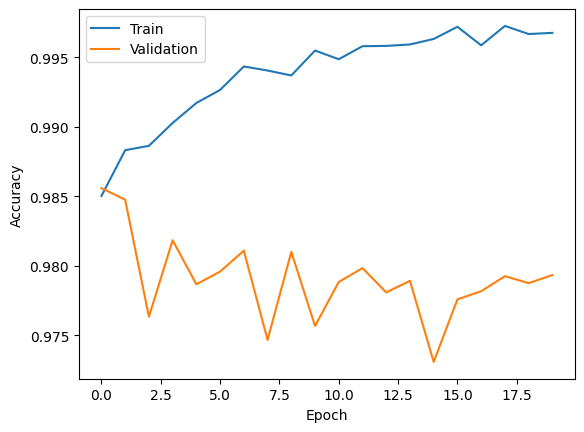

In [38]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

In [39]:
from sklearn.metrics import classification_report

print(classification_report(ytest, ans))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.97      0.98      0.97      1032
           3       0.98      0.95      0.96      1010
           4       0.97      0.99      0.98       982
           5       0.94      0.98      0.96       892
           6       0.98      0.96      0.97       958
           7       0.99      0.96      0.97      1028
           8       0.97      0.97      0.97       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



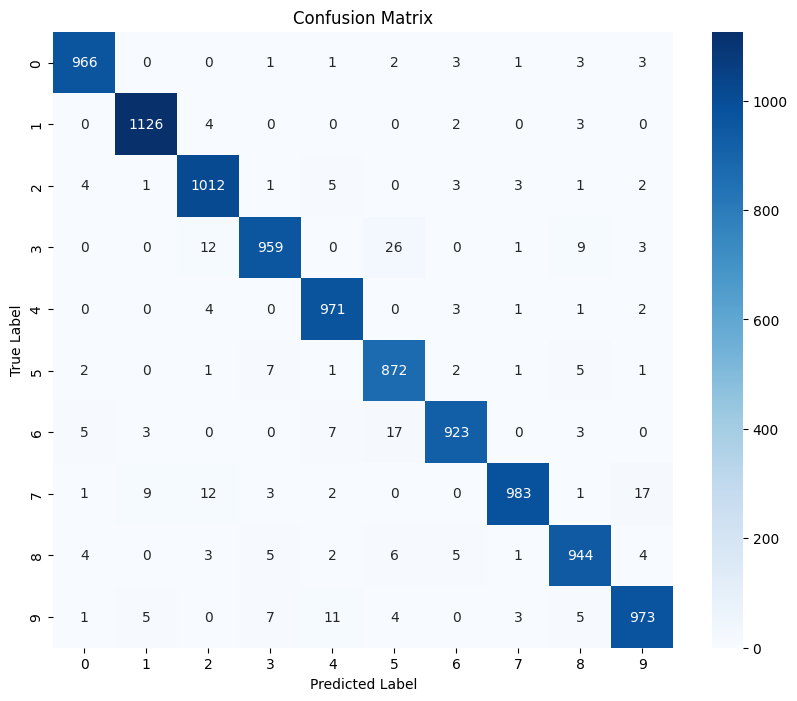

In [48]:
# Calculate the confusion matrix
cm = confusion_matrix(ytest, ans)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

##Hyperparameter Tuning

In [51]:
from keras.optimizers import Adam

optimizer_1 = Adam(learning_rate=0.001)
optimizer_2 = Adam(learning_rate=0.0005)
optimizer_3 = Adam(learning_rate=0.0001)

print(f"Optimizer 1 learning rate: {optimizer_1.learning_rate.numpy()}")
print(f"Optimizer 2 learning rate: {optimizer_2.learning_rate.numpy()}")
print(f"Optimizer 3 learning rate: {optimizer_3.learning_rate.numpy()}")

Optimizer 1 learning rate: 0.0010000000474974513
Optimizer 2 learning rate: 0.0005000000237487257
Optimizer 3 learning rate: 9.999999747378752e-05


In [53]:
from keras.layers import Dropout

Dropout(0.3)

<Dropout name=dropout, built=True>